In [1]:
import sys, os

# 🔥 point to project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Ayush Ranjan\Desktop\TSF Project


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.model_io import load_model
from src.data.load_data import load_raw_data
from src.features.build_features import create_features
from src.data.split_data import train_test_split_time
from src.config import SPLIT_DATE

In [3]:
df = load_raw_data()
df = create_features(df)
df = df.sort_index().dropna()

train, test = train_test_split_time(df, SPLIT_DATE)

print("Train:", train.shape)
print("Test:", test.shape)

Train: 2015-01-14 00:00:00 → 2023-12-29 00:00:00 | 2338 rows
Test:  2024-01-01 00:00:00 → 2026-04-30 00:00:00 | 609 rows
Train: (2338, 21)
Test: (609, 21)


In [4]:
models = ["ARIMA", "SARIMA", "SARIMAX", "Prophet", "RandomForest", "XGBoost"]

preds_dict = {}

for name in models:
    print(f"\nLoading {name}_final...")

    try:
        model = load_model(f"{name}_final")

        # =====================
        # PREDICTION
        # =====================
        if name == "SARIMAX":
            preds = model.predict(test=test)

        elif name == "Prophet":
            preds = model.predict(test=test)

        elif name in ["ARIMA", "SARIMA"]:
            preds = model.predict(len(test))

        else:
            preds = model.predict(test)

        # =====================
        # CLEAN OUTPUT
        # =====================
        preds = np.asarray(preds, dtype=float)
        preds = np.nan_to_num(preds)
        preds = np.clip(preds, -10, 10)

        # 🔥 convert log → price
        preds = np.exp(preds)

        preds_dict[name] = preds

        print(f"{name} predictions shape:", preds.shape)

    except Exception as e:
        print(f"❌ Error in {name}: {e}")


Loading ARIMA_final...
📦 Model loaded: c:\Users\Ayush Ranjan\Desktop\TSF Project\models\ARIMA_final.pkl
ARIMA predictions shape: (609,)

Loading SARIMA_final...
📦 Model loaded: c:\Users\Ayush Ranjan\Desktop\TSF Project\models\SARIMA_final.pkl
SARIMA predictions shape: (609,)

Loading SARIMAX_final...
📦 Model loaded: c:\Users\Ayush Ranjan\Desktop\TSF Project\models\SARIMAX_final.pkl
SARIMAX predictions shape: (609,)

Loading Prophet_final...
📦 Model loaded: c:\Users\Ayush Ranjan\Desktop\TSF Project\models\Prophet_final.pkl
Prophet predictions shape: (609,)

Loading RandomForest_final...
📦 Model loaded: c:\Users\Ayush Ranjan\Desktop\TSF Project\models\RandomForest_final.pkl
RandomForest predictions shape: (609,)

Loading XGBoost_final...
📦 Model loaded: c:\Users\Ayush Ranjan\Desktop\TSF Project\models\XGBoost_final.pkl
XGBoost predictions shape: (609,)


In [5]:
preds_df = pd.DataFrame(preds_dict)

# align index with test
preds_df.index = test.index[:len(preds_df)]

preds_df.head()

,ARIMA,SARIMA,SARIMAX,Prophet,RandomForest,XGBoost
Date,,,,,,
2024-01-01,1430.800049,1431.992414,1393.876919,1306.673056,1292.774684,1278.926290
2024-01-02,1430.800049,1432.161501,1395.653887,1309.584317,1298.981342,1294.953058
2024-01-03,1430.800049,1432.199868,1385.870774,1313.423723,1302.551491,1301.362273
2024-01-04,1430.800049,1432.205135,1384.435190,1316.008279,1292.774684,1284.742710
2024-01-05,1430.800049,1432.206371,1392.783535,1318.977562,1298.981342,1300.842366


In [6]:
actual_price = np.exp(test["target"])
actual_price = actual_price.iloc[:len(preds_df)]

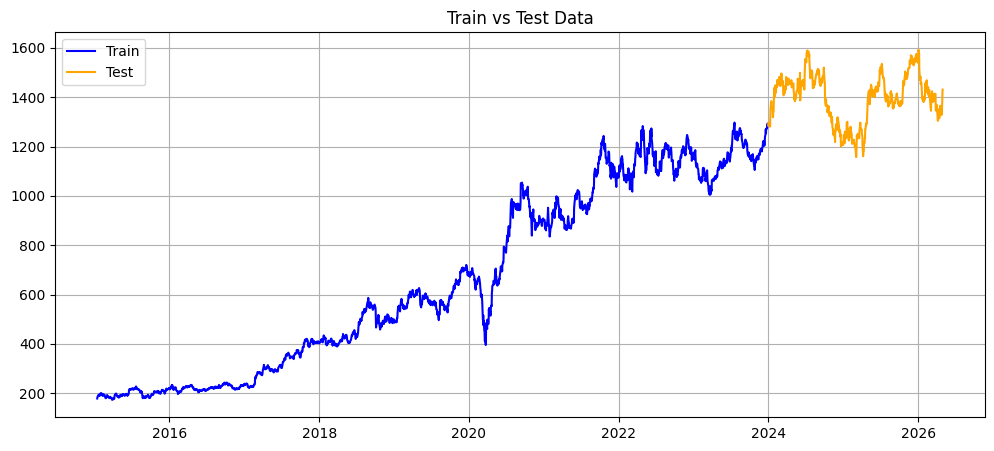

In [7]:
plt.figure(figsize=(12,5))

plt.plot(train.index, np.exp(train["target"]), label="Train", color="blue")
plt.plot(test.index, np.exp(test["target"]), label="Test", color="orange")

plt.title("Train vs Test Data")
plt.legend()
plt.grid()

plt.show()

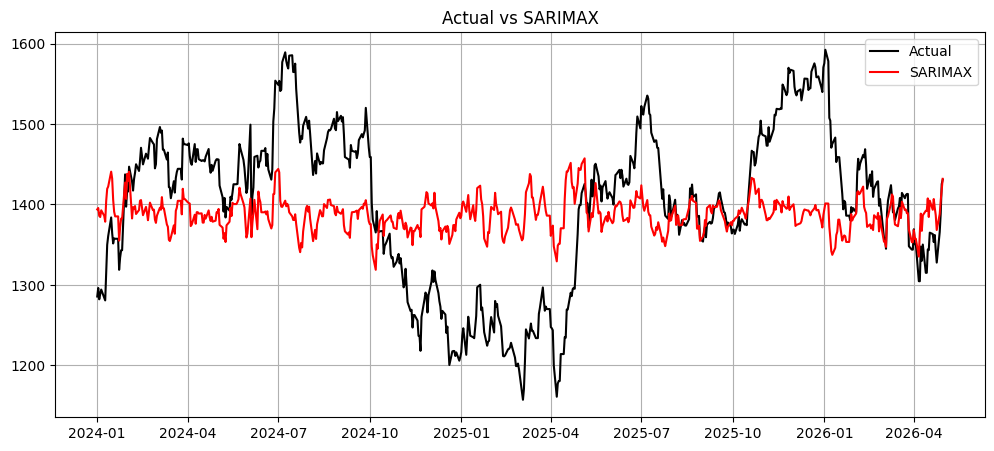

In [8]:
model_name = "SARIMAX"  # change as needed

plt.figure(figsize=(12,5))

plt.plot(actual_price.index, actual_price, label="Actual", color="black")
plt.plot(preds_df.index, preds_df[model_name], label=model_name, color="red")

plt.title(f"Actual vs {model_name}")
plt.legend()
plt.grid()

plt.show()

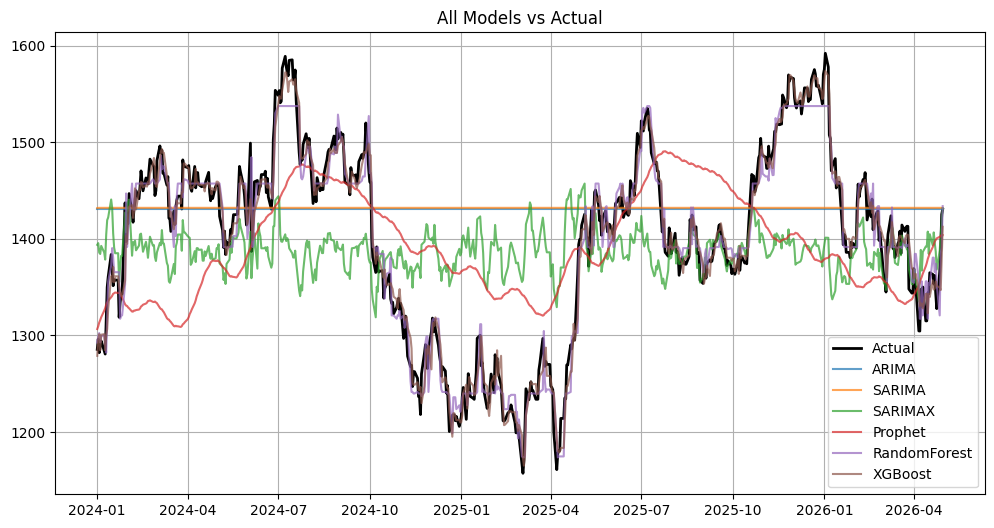

In [9]:
plt.figure(figsize=(12,6))

plt.plot(actual_price.index, actual_price, label="Actual", color="black", linewidth=2)

for col in preds_df.columns:
    plt.plot(preds_df.index, preds_df[col], label=col, alpha=0.7)

plt.title("All Models vs Actual")
plt.legend()
plt.grid()

plt.show()

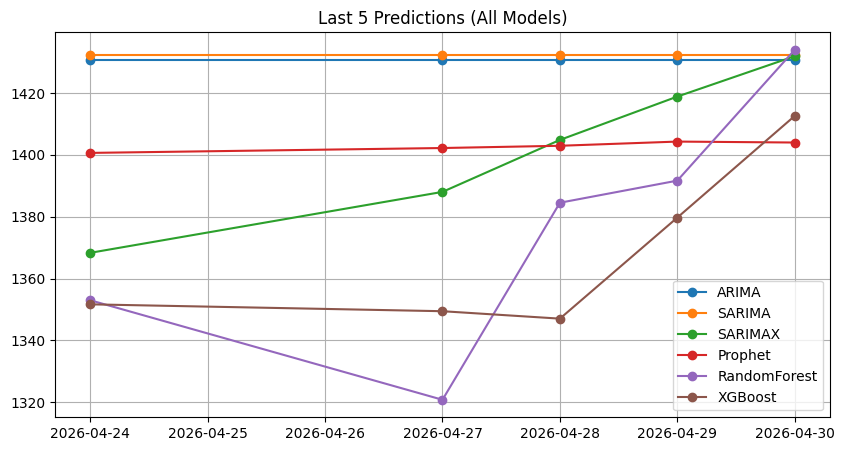

In [11]:
last_preds = preds_df.tail(5)

plt.figure(figsize=(10,5))

for col in last_preds.columns:
    plt.plot(last_preds.index, last_preds[col], marker='o', label=col)

plt.title("Last 5 Predictions (All Models)")
plt.legend()
plt.grid()

plt.show()

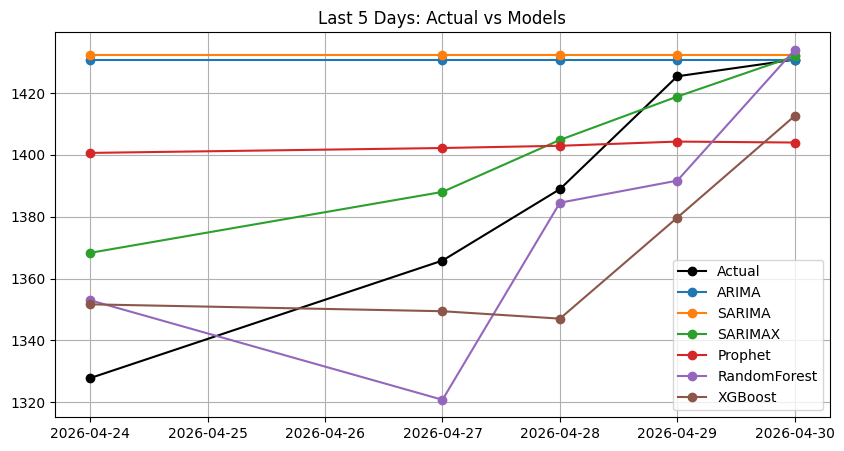

In [12]:
actual_last = actual_price.tail(5)

plt.figure(figsize=(10,5))

plt.plot(actual_last.index, actual_last, marker='o', color='black', label="Actual")

for col in last_preds.columns:
    plt.plot(last_preds.index, last_preds[col], marker='o', label=col)

plt.title("Last 5 Days: Actual vs Models")
plt.legend()
plt.grid()

plt.show()

# Future 5 days plot

In [13]:
df_full = load_raw_data()
df_full = create_features(df_full)
df_full = df_full.sort_index().dropna()

In [14]:
future_preds = {}

for name in models:
    print(f"\nLoading {name}_final...")

    try:
        model = load_model(f"{name}_final")

        # =====================
        # FUTURE PREDICTION
        # =====================
        if name == "SARIMAX":
            preds = model.predict(test=df_full.tail(5), steps=5)

        elif name == "Prophet":
            preds = model.predict(test=df_full.tail(5), steps=5)

        elif name in ["ARIMA", "SARIMA"]:
            preds = model.predict(5)

        else:
            preds = model.predict_future(df_full, steps=5)

        # =====================
        # CLEAN OUTPUT
        # =====================
        preds = np.asarray(preds, dtype=float)
        preds = np.nan_to_num(preds)
        preds = np.clip(preds, -10, 10)

        # convert log → price
        preds = np.exp(preds)

        future_preds[name] = preds

        print(f"{name} future preds:", preds)

    except Exception as e:
        print(f"❌ Error in {name}: {e}")


Loading ARIMA_final...
📦 Model loaded: c:\Users\Ayush Ranjan\Desktop\TSF Project\models\ARIMA_final.pkl
ARIMA future preds: [1430.80004883 1430.80004883 1430.80004883 1430.80004883 1430.80004883]

Loading SARIMA_final...
📦 Model loaded: c:\Users\Ayush Ranjan\Desktop\TSF Project\models\SARIMA_final.pkl
SARIMA future preds: [1431.99241377 1432.1615006  1432.19986845 1432.20513541 1432.2063714 ]

Loading SARIMAX_final...
📦 Model loaded: c:\Users\Ayush Ranjan\Desktop\TSF Project\models\SARIMAX_final.pkl
SARIMAX future preds: [1368.65960531 1387.94371484 1404.83824108 1418.83298153 1431.90278615]

Loading Prophet_final...
📦 Model loaded: c:\Users\Ayush Ranjan\Desktop\TSF Project\models\Prophet_final.pkl
Prophet future preds: [1403.81028542 1399.90568421 1398.99992905 1398.87008245 1397.25744937]

Loading RandomForest_final...
📦 Model loaded: c:\Users\Ayush Ranjan\Desktop\TSF Project\models\RandomForest_final.pkl
RandomForest future preds: [1433.97132675 1444.41728541 1457.37040955 1457.370

In [15]:
future_df = pd.DataFrame(future_preds)

# create future dates
future_dates = pd.date_range(
    start=df_full.index[-1],
    periods=6,
    freq="B"
)[1:]

future_df.index = future_dates

future_df

,ARIMA,SARIMA,SARIMAX,Prophet,RandomForest,XGBoost
2026-05-01,1430.800049,1431.992414,1368.659605,1403.810285,1433.971327,1412.589787
2026-05-04,1430.800049,1432.161501,1387.943715,1399.905684,1444.417285,1406.460789
2026-05-05,1430.800049,1432.199868,1404.838241,1398.999929,1457.370410,1407.706743
2026-05-06,1430.800049,1432.205135,1418.832982,1398.870082,1457.370410,1397.472038
2026-05-07,1430.800049,1432.206371,1431.902786,1397.257449,1457.370410,1396.295065


In [16]:
last_actual = np.exp(df_full["target"]).tail(20)

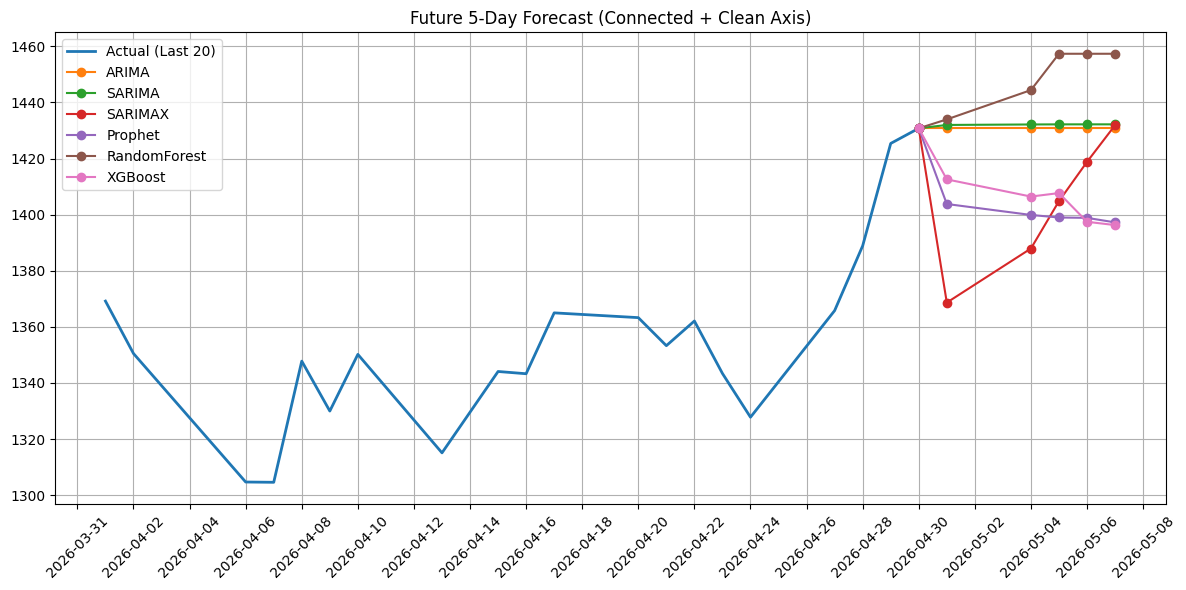

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

plt.figure(figsize=(12,6))

# =====================
# 1. COMBINE SERIES (IMPORTANT FIX)
# =====================
combined = pd.concat([
    last_actual,
    future_df.iloc[:1]  # 🔥 first forecast point ensures connection
])

# plot actual
plt.plot(last_actual.index, last_actual, label="Actual (Last 20)", linewidth=2)

# plot each model WITH connection
for col in future_df.columns:
    
    # connect last actual point to first prediction
    connect_series = pd.concat([
        last_actual.iloc[-1:],      # last actual point
        future_df[col]              # predictions
    ])
    
    plt.plot(connect_series.index, connect_series, marker='o', label=col)

# =====================
# 2. FIX X-AXIS (every 2 days)
# =====================
ax = plt.gca()

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)

# =====================
# FINAL TOUCH
# =====================
plt.title("Future 5-Day Forecast (Connected + Clean Axis)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

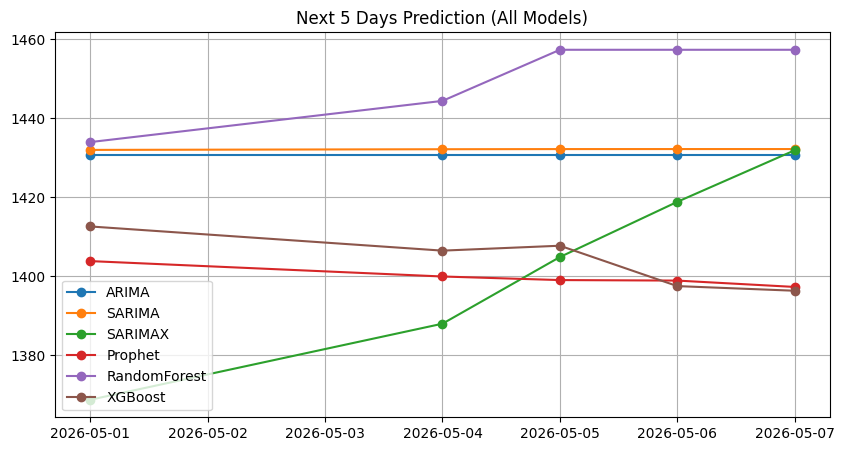

In [18]:
plt.figure(figsize=(10,5))

for col in future_df.columns:
    plt.plot(future_df.index, future_df[col], marker='o', label=col)

plt.title("Next 5 Days Prediction (All Models)")
plt.legend()
plt.grid()

plt.show()

# Investment Growth

In [22]:
print(future_df.head())

                  ARIMA       SARIMA      SARIMAX      Prophet  RandomForest  \
2026-05-01  1430.800049  1431.992414  1368.659605  1403.810285   1433.971327   
2026-05-04  1430.800049  1432.161501  1387.943715  1399.905684   1444.417285   
2026-05-05  1430.800049  1432.199868  1404.838241  1398.999929   1457.370410   
2026-05-06  1430.800049  1432.205135  1418.832982  1398.870082   1457.370410   
2026-05-07  1430.800049  1432.206371  1431.902786  1397.257449   1457.370410   

                XGBoost  
2026-05-01  1412.589787  
2026-05-04  1406.460789  
2026-05-05  1407.706743  
2026-05-06  1397.472038  
2026-05-07  1396.295065  


In [23]:
initial_investment = 100

investment_df = pd.DataFrame(index=future_df.index)

for col in future_df.columns:
    
    # normalize relative to first prediction
    normalized = future_df[col] / future_df[col].iloc[0]
    
    investment_df[col] = initial_investment * normalized

investment_df

,ARIMA,SARIMA,SARIMAX,Prophet,RandomForest,XGBoost
2026-05-01,100.0,100.000000,100.000000,100.000000,100.000000,100.000000
2026-05-04,100.0,100.011808,101.408978,99.721857,100.728464,99.566116
2026-05-05,100.0,100.014487,102.643363,99.657336,101.631768,99.654320
2026-05-06,100.0,100.014855,103.665877,99.648086,101.631768,98.929785
2026-05-07,100.0,100.014941,104.620812,99.533211,101.631768,98.846465


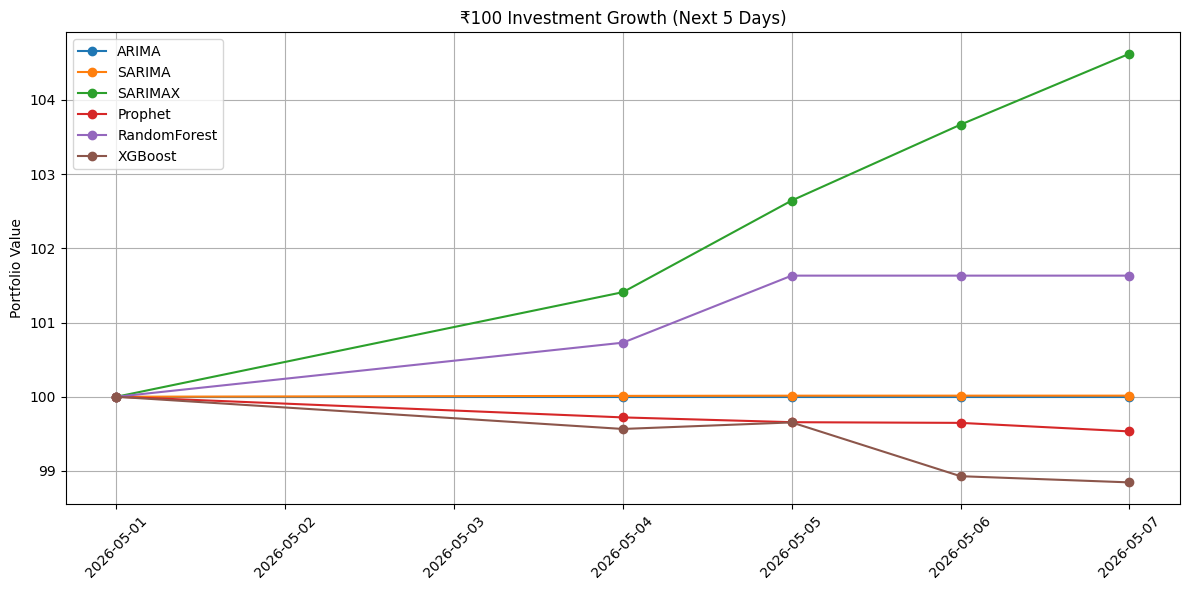

In [24]:
plt.figure(figsize=(12,6))

for col in investment_df.columns:
    plt.plot(investment_df.index, investment_df[col], marker='o', label=col)

plt.title("₹100 Investment Growth (Next 5 Days)")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()